In [ ]:
!pip install mp_toolkits

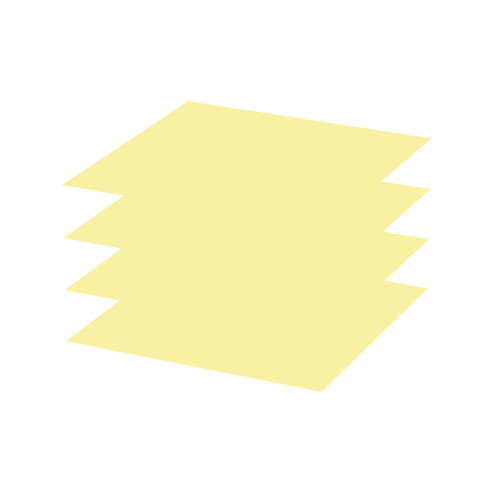

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# --- configurable knobs ------------------------------------------------------
n_points_per_side = 9        # inner (unpadded) grid size
n_layers          = 4        # how many “slices” you want to stack
padding           = 2        # rows / cols of padding around the grid
point_spacing     = 0.1      # distance between neighbouring dots
layer_spacing_z   = 1.     # gap between successive layers
pad_color         = "#F8F1A3"  # light-pink padding colour
# -----------------------------------------------------------------------------


# pre-compute the inner–grid (unpadded) coordinates once
xs_inner, ys_inner = np.meshgrid(
    np.arange(n_points_per_side) * point_spacing,
    np.arange(n_points_per_side) * point_spacing
)
xs_inner, ys_inner = xs_inner.ravel(), ys_inner.ravel()

# Create a colour gradient for the points (blue → red)
point_colors = plt.cm.coolwarm(
    np.linspace(0, 1, n_points_per_side ** 2)
)

# -----------------------------------------------------------------------------    
# plotting
# -----------------------------------------------------------------------------    
fig = plt.figure(figsize=(5, 7))
ax  = fig.add_subplot(111, projection="3d")

# Use the same aspect ratio for x & y so the grid is square
ax.set_box_aspect([1, 1, 0.6])   

for k in range(n_layers):
    z = k * layer_spacing_z

    # 1) draw the padding rectangle (one large Quad on the Z = z plane)
    w = (n_points_per_side - 1 + 2 * padding) * point_spacing   # overall width
    rect = [
        (-padding * point_spacing, -padding * point_spacing, z),   # lower-left
        (w - padding * point_spacing, -padding * point_spacing, z),
        (w - padding * point_spacing, w - padding * point_spacing, z),
        (-padding * point_spacing,  w - padding * point_spacing, z)
    ]
    pad = Poly3DCollection([rect], facecolors=pad_color, linewidths=0)
    ax.add_collection3d(pad)

    # 2) scatter the equidistant points
    ax.scatter(xs_inner,
               ys_inner,
               z,
               c=point_colors,
               s=35,
               edgecolors="k",
               linewidths=0.25,
               depthshade=False)

# cosmetic tweaks -------------------------------------------------------------
ax.view_init(elev=22, azim=-65)      # tilt & rotate for a “skewed” look
ax.set_axis_off()                    # hide the 3-D box, ticks, etc.
plt.tight_layout()
plt.show()


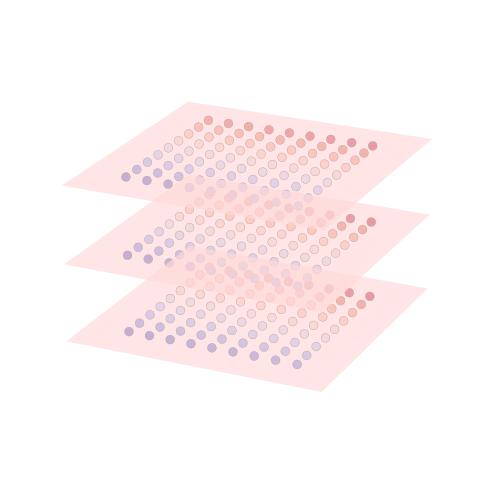

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---------------------------------------------------------------------------
# 🔧 easy-to-tweak knobs
# ---------------------------------------------------------------------------
n_points_per_side = 9      # inner-grid size  (e.g. 9×9)
n_layers          = 3      # how many slices to draw
padding           = 2      # cells of padding around the grid
point_spacing     = 1.0    # distance between neighbouring dots
layer_spacing_z   = 1.5    # gap between successive layers
pad_color         = "#FFDADA"   # light-pink padding colour
# ---------------------------------------------------------------------------

# pre-compute inner-grid coordinates once
xs_inner, ys_inner = np.meshgrid(
    np.arange(n_points_per_side) * point_spacing,
    np.arange(n_points_per_side) * point_spacing
)
xs_inner, ys_inner = xs_inner.ravel(), ys_inner.ravel()

# simple colour gradient for the sample points
point_colors = plt.cm.coolwarm(np.linspace(0, 1, n_points_per_side**2))

fig = plt.figure(figsize=(5, 7))
ax  = fig.add_subplot(111, projection="3d")
ax.set_box_aspect([1, 1, 0.6])          # keep x & y square

for k in range(n_layers):
    z = k * layer_spacing_z

    # -----------------------------------------------------------------------
    # 1)  padding rectangle (a single Quad in the Z = z plane)
    # -----------------------------------------------------------------------
    start = -padding * point_spacing                        # left / bottom
    size  = (n_points_per_side - 1 + 2*padding) * point_spacing
    rect  = [
        (start,        start,        z),
        (start+size,   start,        z),
        (start+size,   start+size,   z),
        (start,        start+size,   z)
    ]
    pad = Poly3DCollection([rect],
                           facecolors=pad_color,
                           alpha=0.70,      # slight transparency
                           linewidths=0)
    ax.add_collection3d(pad)

    # -----------------------------------------------------------------------
    # 2)  scatter the equidistant sample points (slightly above the plane so
    #     they never get hidden by the Quad’s surface)
    # -----------------------------------------------------------------------
    ax.scatter(xs_inner,
               ys_inner,
               z + 0.01,          # tiny lift to avoid z-fighting
               c=point_colors,
               s=40,
               edgecolors="k",
               linewidths=0.25,
               depthshade=False)

    # -----------------------------------------------------------------------
    # 3)  write “Padding” down the left & bottom borders of every slice
    # -----------------------------------------------------------------------
    # left-hand words (vertical)
    y_ticks = np.linspace(start, start+size, padding+1, endpoint=False)
    # for y in y_ticks:
    #     # ax.text(start-0.4*point_spacing, y, z,
    #     #         "Padding",
    #     #         ha='right', va='center',
    #     #         rotation=90, fontsize=10)

    # bottom words (horizontal)
    x_ticks = np.linspace(start, start+size, padding+1, endpoint=False)
    # for x in x_ticks:
    #     ax.text(x, start-0.4*point_spacing, z,
    #             "Padding",
    #             ha='center', va='top',
    #             rotation=0, fontsize=10)

# cosmetic tweaks ------------------------------------------------------------
ax.view_init(elev=22, azim=-65)   # tilt & rotate for a skewed look
ax.set_axis_off()                # hide axes & spines
plt.tight_layout()
plt.show()


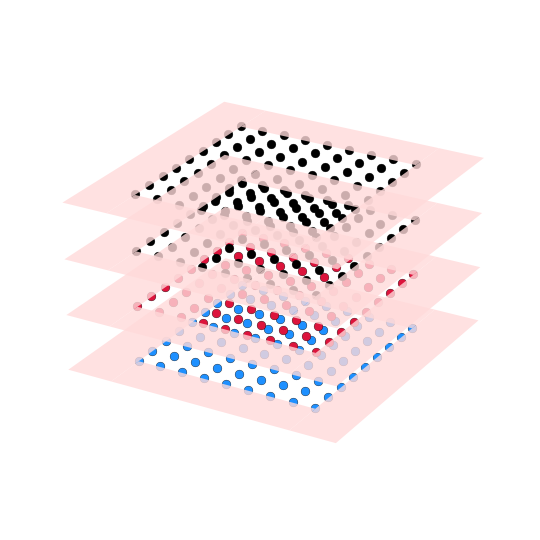

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ── knobs you may want to adjust ──────────────────────────────────────────────
n_points_per_side = 9        # inner lattice size  (e.g. 9→9×9 = 81 points)
padding           = 2        # cells of padding around the grid
n_layers          = 4        # how many slices to stack
point_spacing     = 1.0      # distance between neighbouring dots
layer_spacing_z   = 1.5      # vertical gap between successive slices
pad_color         = "#FFDADA"        # pink tint for padding area
text_step         = 1.5              # distance (in data-units) between words
# ──────────────────────────────────────────────────────────────────────────────

# Convenience shortcut – pick layer colours: 0→blue, 1→red, 2+→black
def colour_for_layer(k):
    return {0: "dodgerblue", 1: "crimson"}.get(k, "black")

# Pre-compute the inner-grid coordinates once
xs_inner, ys_inner = np.meshgrid(
    np.arange(n_points_per_side) * point_spacing,
    np.arange(n_points_per_side) * point_spacing
)
xs_inner, ys_inner = xs_inner.ravel(), ys_inner.ravel()

# Helpful extents
inner_min  = 0
inner_max  = (n_points_per_side - 1) * point_spacing
outer_min  = inner_min - padding * point_spacing
outer_max  = inner_max + padding * point_spacing

fig = plt.figure(figsize=(5.5, 7))
ax  = fig.add_subplot(111, projection="3d")
ax.set_box_aspect([1, 1, 0.6])         # keep the rectangles square after tilt

for k in range(n_layers):
    z = k * layer_spacing_z

    # ── 1) draw the *four* padding strips (left / right / bottom / top) ──────
    borders = [
        # left strip
        [(outer_min, outer_min, z),
         (inner_min, outer_min, z),
         (inner_min, outer_max, z),
         (outer_min, outer_max, z)],
        # right strip
        [(inner_max, outer_min, z),
         (outer_max, outer_min, z),
         (outer_max, outer_max, z),
         (inner_max, outer_max, z)],
        # bottom strip
        [(inner_min, outer_min, z),
         (inner_max, outer_min, z),
         (inner_max, inner_min, z),
         (inner_min, inner_min, z)],
        # top strip
        [(inner_min, inner_max, z),
         (inner_max, inner_max, z),
         (inner_max, outer_max, z),
         (inner_min, outer_max, z)]
    ]
    ax.add_collection3d(
        Poly3DCollection(
            borders,
            facecolors=pad_color,
            alpha=0.80,
            linewidths=0                      # no border lines
        )
    )

    # ── 2) scatter the equidistant sample points (uniform colour per slice) ──
    ax.scatter(xs_inner,
               ys_inner,
               z + 0.02,                       # tiny lift avoids z-fighting
               c=colour_for_layer(k),
               s=40,
               edgecolors="k",
               linewidths=0.25,
               depthshade=False)

    # ── 3) write “Padding” down the left & bottom edges ─────────────────────
    y_positions = np.arange(inner_min, inner_max + 0.01, text_step)
    # for y in y_positions:
    #     ax.text(outer_min - 0.35 * point_spacing,   # a smidge to the left
    #             y,
    #             z,
    #             "Padding",
    #             ha='right', va='center',
    #             rotation=90, fontsize=10)

    x_positions = np.arange(inner_min, inner_max + 0.01, text_step)
    # for x in x_positions:
    #     ax.text(x,
    #             outer_min - 0.35 * point_spacing,   # a smidge below
    #             z,
    #             "Padding",
    #             ha='center', va='top',
    #             rotation=0, fontsize=10)

# ── final cosmetic tweaks ────────────────────────────────────────────────────
ax.view_init(elev=25, azim=-60)  # tilt & rotate for the 3-D “skewed” view
ax.set_axis_off()                # hide axes, ticks, grids
plt.tight_layout()
plt.show()


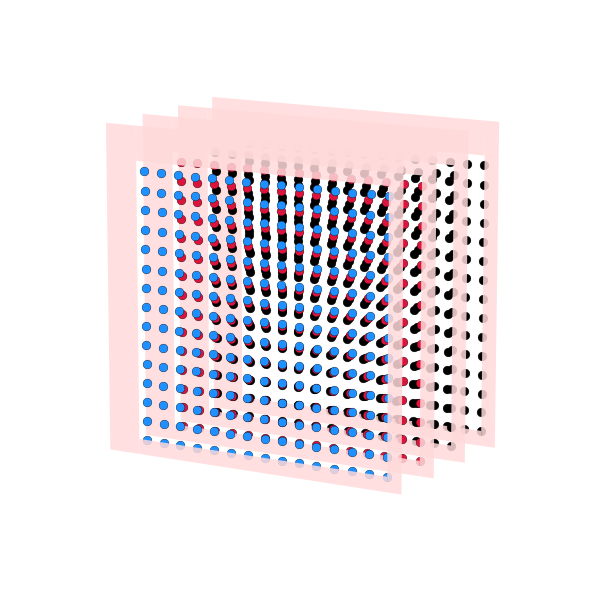

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ── easy-to-tweak knobs ──────────────────────────────────────────────────────
n_points_per_side = 15     # inner lattice size  (20 ➜ 20×20 points)
padding           = 1.8     # cells of padding around the grid
n_layers          = 4     # how many slices to draw
point_spacing     = 0.5   # distance between neighbouring dots
layer_spacing_y   = 3   # gap (in the y-direction) between successive slices
pad_color         = "#FFDADA"      # pink tint for the padding strips
# ─────────────────────────────────────────────────────────────────────────────

# helper → colour of every slice
def colour_for_layer(k):
    return {0: "dodgerblue", 1: "crimson"}.get(k, "black")

# build the inner-grid once
xs_inner, zs_inner = np.meshgrid(
    np.arange(n_points_per_side) * point_spacing,
    np.arange(n_points_per_side) * point_spacing
)
xs_inner, zs_inner = xs_inner.ravel(), zs_inner.ravel()   # flatten

# extents
inner_min  = 0
inner_max  = (n_points_per_side - 1) * point_spacing
outer_min  = inner_min - padding * point_spacing
outer_max  = inner_max + padding * point_spacing
mid_inner  = 0.5 * (inner_min + inner_max)                # centre of inner area
mid_outer  = 0.5 * (outer_min + outer_max)                # centre of the border

fig = plt.figure(figsize=(6, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.set_box_aspect([1, 0.6, 1])        # [x : y : z] ratio  → slices look square

for k in range(n_layers):
    # every slice sits at a different y (depth) but the same z-plane (z=0)
    y_shift = -k * layer_spacing_y
    y_c     = y_shift                 # shorthand: current slice’s y-coordinate

    # ── 1) draw the FOUR padding strips (pink) ───────────────────────────────
    borders = [
        # left
        [(outer_min, y_c, outer_min), (inner_min, y_c, outer_min),
         (inner_min, y_c, outer_max), (outer_min, y_c, outer_max)],
        # right
        [(inner_max, y_c, outer_min), (outer_max, y_c, outer_min),
         (outer_max, y_c, outer_max), (inner_max, y_c, outer_max)],
        # bottom
        [(inner_min, y_c, outer_min), (inner_max, y_c, outer_min),
         (inner_max, y_c, inner_min), (inner_min, y_c, inner_min)],
        # top
        [(inner_min, y_c, inner_max), (inner_max, y_c, inner_max),
         (inner_max, y_c, outer_max), (inner_min, y_c, outer_max)],
    ]
    ax.add_collection3d(
        Poly3DCollection(
            borders,
            facecolors=pad_color,
            alpha=0.85,
            linewidths=0
        )
    )

    # ── 2) scatter the sample points (one solid colour per slice) ────────────
    ax.scatter(xs_inner,
               np.full_like(xs_inner, y_c) + 0.01,      # tiny lift (avoid z-fight)
               zs_inner,
               c=colour_for_layer(k),
               s=40,
               edgecolors="k", linewidths=0.25,
               depthshade=False)

    # ── 3) put ONE “Padding” label in the middle of each coloured strip ─────
    # left strip  (vertical text)
    # ax.text(outer_min - 0.45 * point_spacing, y_c, mid_outer,
    #         "Padding", ha='right', va='center', rotation=90, fontsize=11)
    # # bottom strip (horizontal text)
    # ax.text(mid_outer, y_c, outer_min - 0.45 * point_spacing,
    #         "Padding", ha='center', va='top', rotation=0, fontsize=11)
    # # right strip (vertical text)
    # ax.text(outer_max + 0.45 * point_spacing, y_c, mid_outer,
    #         "Padding", ha='left', va='center', rotation=270, fontsize=11)
    # # top strip (horizontal text)
    # ax.text(mid_outer, y_c, outer_max + 0.45 * point_spacing,
    #         "Padding", ha='center', va='bottom', rotation=0, fontsize=11)

# ── final cosmetics ──────────────────────────────────────────────────────────
ax.view_init(elev=12, azim=120)   # shallow elevation + azimuth → front-to-back stack with left skew
ax.set_axis_off()
plt.tight_layout()
plt.show()


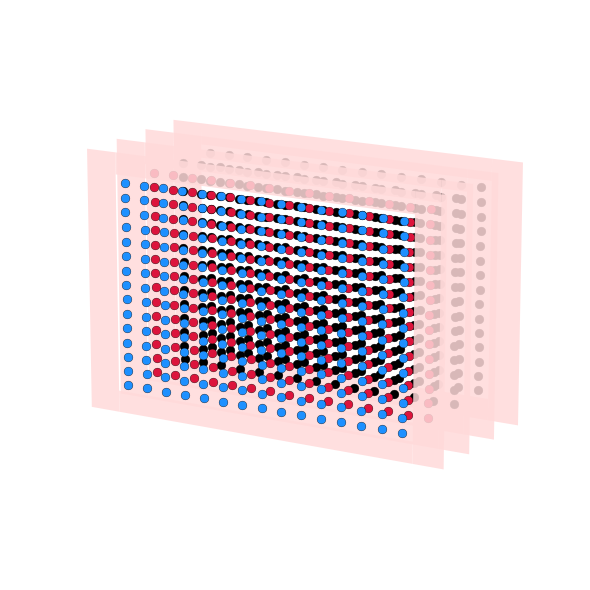

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ── easy-to-tweak knobs ──────────────────────────────────────────────────
n_points_per_side = 15      # inner lattice size (9 → 9 × 9 points)
padding           = 2      # padding cells around the grid
n_layers          = 4      # number of slices
point_spacing     = 0.1    # distance between neighbouring dots
layer_spacing_y   = 2.0    # gap (depth) between successive slices
pad_color         = "#FFDADA"   # pink tint for padding strips
edge_color        = "#666666"   # outline colour for each sheet
# ─────────────────────────────────────────────────────────────────────────

# helper → uniform colour per slice
def colour_for_layer(k):
    return {0: "dodgerblue", 1: "crimson"}.get(k, "black")

# inner grid (scatter) ----------------------------------------------------
xs_inner, zs_inner = np.meshgrid(
    np.arange(n_points_per_side) * point_spacing,
    np.arange(n_points_per_side) * point_spacing
)
xs_inner, zs_inner = xs_inner.ravel(), zs_inner.ravel()

# key extents -------------------------------------------------------------
inner_min = 0
inner_max = (n_points_per_side - 1) * point_spacing

# NOTE:  the padding strips *stop one spacing unit before* the inner grid,
# so they never sit under any scatter points
outer_min = inner_min - padding * point_spacing
outer_max = inner_max + padding * point_spacing

# convenience centres (for label placement)
mid_z = 0.5 * (outer_min + outer_max)   # centre along the vertical (z) axis
mid_x = 0.5 * (outer_min + outer_max)   # centre along the horizontal (x) axis

# borders’ inner edges (one spacing cell away from the points)
left_x1   = inner_min - point_spacing*0.5
right_x0  = inner_max + point_spacing*0.5
bottom_z1 = inner_min - point_spacing*0.5
top_z0    = inner_max + point_spacing*0.5

fig = plt.figure(figsize=(6, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.set_box_aspect([1.5, 0.6, 1])    # [x : y : z] – keeps rectangles square

for k in range(n_layers):
    y_c = -k * layer_spacing_y    # slices recede along the negative y-axis
    outline = [
    (outer_min, y_c, outer_min), (outer_max, y_c, outer_min),
    (outer_max, y_c, outer_max), (outer_min, y_c, outer_max),
    (outer_min, y_c, outer_min)
    ]

    # xs, ys, zs = zip(*outline)
    # ax.plot(xs, ys, zs, color=edge_color, linewidth=1.2)
    # ──────────────────────────────────────────────────────────────────
    # 1) four non-overlapping pink padding strips
    # ──────────────────────────────────────────────────────────────────
    borders = [
        # left strip
        [(outer_min, y_c, outer_min), (left_x1, y_c, outer_min),
         (left_x1,  y_c, outer_max),  (outer_min, y_c, outer_max)],

        # right strip
        [(right_x0, y_c, outer_min),  (outer_max, y_c, outer_min),
         (outer_max, y_c, outer_max), (right_x0,  y_c, outer_max)],

        # bottom strip
        [(left_x1,  y_c, outer_min),  (right_x0, y_c, outer_min),
         (right_x0, y_c, bottom_z1),  (left_x1,  y_c, bottom_z1)],

        # top strip
        [(left_x1,  y_c, top_z0),     (right_x0, y_c, top_z0),
         (right_x0, y_c, outer_max),  (left_x1,  y_c, outer_max)],
    ]
    ax.add_collection3d(
        Poly3DCollection(
            borders,
            facecolors=pad_color,
            alpha=0.85,
            linewidths=0          # no internal edges – just the fill
        )
    )

    # ──────────────────────────────────────────────────────────────────
    # 2) scatter the inner grid (one colour per slice)
    # ──────────────────────────────────────────────────────────────────
    ax.scatter(xs_inner,
               np.full_like(xs_inner, y_c) + 0.02,   # tiny lift ➜ no z-fighting
               zs_inner,
               c=colour_for_layer(k),
               s=40,
               edgecolors="k", linewidths=0.25,
               depthshade=False)

    # ──────────────────────────────────────────────────────────────────
    # 3) outline the whole slice for clarity
    # ──────────────────────────────────────────────────────────────────


    # ──────────────────────────────────────────────────────────────────
    # 4) place ONE “Padding” label in the centre of each strip
    # ──────────────────────────────────────────────────────────────────
    # left
    # ax.text(0.5 * (outer_min + left_x1), y_c, mid_z,
    #         "Padding", ha="right", va="center",
    #         rotation=90, fontsize=11)
    # # right
    # ax.text(0.5 * (right_x0 + outer_max), y_c, mid_z,
    #         "Padding", ha="left", va="center",
    #         rotation=270, fontsize=11)
    # # bottom
    # ax.text(mid_x, y_c, 0.5 * (outer_min + bottom_z1),
    #         "Padding", ha="center", va="top",
    #         rotation=0, fontsize=11)
    # # top
    # ax.text(mid_x, y_c, 0.5 * (top_z0 + outer_max),
    #         "Padding", ha="center", va="bottom",
    #         rotation=0, fontsize=11)

# ── camera & cosmetics ───────────────────────────────────────────────────────
ax.view_init(elev=15, azim=120)   # shallow elevation + left-skew azimuth
ax.set_axis_off()
plt.tight_layout()
plt.show()


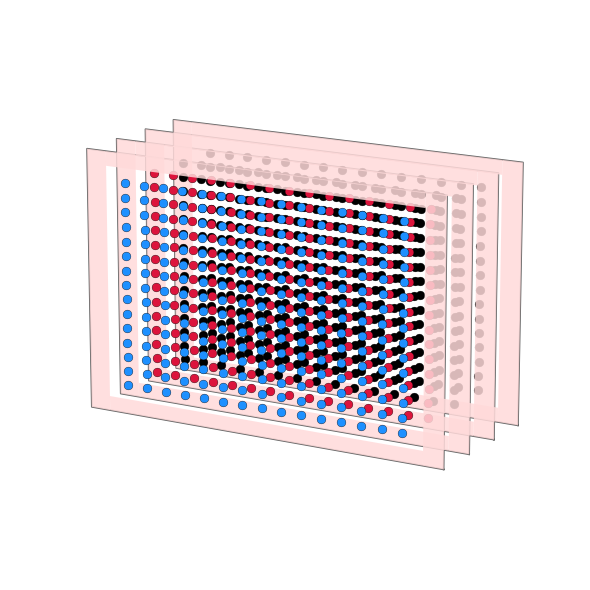

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ── tweakables ───────────────────────────────────────────────────────────────
n_points_per_side = 15     # inner lattice size (15 → 15 × 15 points)
padding_cells     = 2      # padding cells around the grid
point_spacing     = 0.10   # distance between neighbouring dots  (in data-units)
n_layers          = 4      # number of slices
layer_spacing_y   = 2.0    # gap (depth) between successive slices   (data-units)

pad_color  = "#FFDADA"     # pink tint for padding strips
edge_color = "#666666"     # outline colour for each sheet
# ─────────────────────────────────────────────────────────────────────────────

# colour per slice:   front → blue, second → red, others → black
def colour_for_layer(k):
    return {0: "dodgerblue", 1: "crimson"}.get(k, "black")

# ---------------------------------------------------------------------------
# 1) inner grid coordinates (scatter points)
# ---------------------------------------------------------------------------
xs_inner, zs_inner = np.meshgrid(
    np.arange(n_points_per_side) * point_spacing,
    np.arange(n_points_per_side) * point_spacing
)
xs_inner, zs_inner = xs_inner.ravel(), zs_inner.ravel()

# ---------------------------------------------------------------------------
# 2) geometric extents
# ---------------------------------------------------------------------------
inner_min = 0
inner_max = (n_points_per_side - 1) * point_spacing

# how far the coloured padding extends *away* from the points:
strip_offset   = point_spacing                         # one full cell
outer_min      = inner_min - (padding_cells * point_spacing)
outer_max      = inner_max + (padding_cells * point_spacing)
left_inner_x   = inner_min - strip_offset              # inner edge of left strip
right_inner_x  = inner_max + strip_offset              # inner edge of right strip
bottom_inner_z = inner_min - strip_offset              # inner edge of bottom strip
top_inner_z    = inner_max + strip_offset              # inner edge of top strip

mid_x = 0.5 * (outer_min + outer_max)                  # centres for labels
mid_z = mid_x                                          # square geometry → same value

# ---------------------------------------------------------------------------
# 3) create the figure / axes
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(6, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.set_box_aspect([1.5, 0.6, 1])     # [x : y : z]

# ---------------------------------------------------------------------------
# 4) draw slices BACK → FRONT so the nearest outline is always on top
# ---------------------------------------------------------------------------
for k in reversed(range(n_layers)):                    # back slice first!
    y_c = -k * layer_spacing_y

    # ── 4a.  four slim padding strips for this slice ───────────────────────
    borders = [
        # left strip
        [(outer_min, y_c, outer_min), (left_inner_x, y_c, outer_min),
         (left_inner_x, y_c, outer_max), (outer_min, y_c, outer_max)],
        # right strip
        [(right_inner_x, y_c, outer_min), (outer_max, y_c, outer_min),
         (outer_max,     y_c, outer_max), (right_inner_x, y_c, outer_max)],
        # bottom strip
        [(left_inner_x,  y_c, outer_min), (right_inner_x, y_c, outer_min),
         (right_inner_x, y_c, bottom_inner_z), (left_inner_x, y_c, bottom_inner_z)],
        # top strip
        [(left_inner_x,  y_c, top_inner_z), (right_inner_x, y_c, top_inner_z),
         (right_inner_x, y_c, outer_max),    (left_inner_x, y_c, outer_max)],
    ]
    ax.add_collection3d(
        Poly3DCollection(
            borders,
            facecolors=pad_color,
            alpha=0.85,
            linewidths=0          # no inner edges
        )
    )

    # ── 4b.  scatter the points (small z-lift avoids z-fighting) ───────────
    ax.scatter(xs_inner,
               np.full_like(xs_inner, y_c) + 0.02,
               zs_inner,
               c=colour_for_layer(k),
               s=40,
               edgecolors="k", linewidths=0.25,
               depthshade=False)

    # ── 4c.  dark outline (slightly in front of its own strip) ─────────────
    outline_eps = 1e-3                       # nudge toward the camera
    outline_y   = y_c + outline_eps
    outline = [
        (outer_min, y_c, outer_min), (outer_max, y_c, outer_min),
        (outer_max, y_c, outer_max), (outer_min, y_c, outer_max),
        (outer_min, y_c, outer_min)
    ]
    xs, ys, zs = zip(*outline)
    ax.plot(xs, ys, zs, color=edge_color, linewidth=1.2)

    # ──────────────────────────────────────────────────────────────────
    # 4) place ONE “Padding” label in the centre of each strip
    # ──────────────────────────────────────────────────────────────────
    # left
    # ax.text(0.5 * (outer_min + left_x1), y_c, mid_z,
    #         "Padding", ha="right", va="center",
    #         rotation=90, fontsize=11)
    # # right
    # ax.text(0.5 * (right_x0 + outer_max), y_c, mid_z,
    #         "Padding", ha="left", va="center",
    #         rotation=270, fontsize=11)
    # # bottom
    # ax.text(mid_x, y_c, 0.5 * (outer_min + bottom_z1),
    #         "Padding", ha="center", va="top",
    #         rotation=0, fontsize=11)
    # # top
    # ax.text(mid_x, y_c, 0.5 * (top_z0 + outer_max),
    #         "Padding", ha="center", va="bottom",
    #         rotation=0, fontsize=11)

# ── camera & cosmetics ───────────────────────────────────────────────────────
ax.view_init(elev=15, azim=120)   # shallow elevation + left-skew azimuth
ax.set_axis_off()
plt.tight_layout()
plt.show()

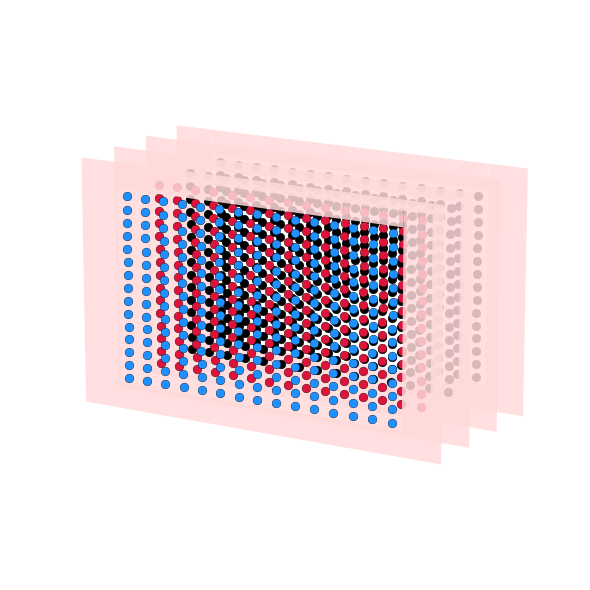

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ── knobs you can play with ─────────────────────────────────────────────
n_points_per_side = 15     # inner lattice size (15 × 15 points)
padding           = 2      # padding cells around the grid
n_layers          = 4      # number of slices to draw
point_spacing     = 0.1    # distance between neighbouring dots
layer_spacing_y   = 2.0    # gap (depth) between successive slices
pad_color         = "#FFDADA"    # pink tint for padding strips
edge_color        = "#666666"    # outline colour for each sheet
# ────────────────────────────────────────────────────────────────────────

# helper → per-slice point colour
def colour_for_layer(k):
    return {0: "dodgerblue", 1: "crimson"}.get(k, "black")

# (x, z) coordinates for all scatter points in the INNER grid -------------
xs_inner, zs_inner = np.meshgrid(
    np.arange(n_points_per_side) * point_spacing,
    np.arange(n_points_per_side) * point_spacing
)
xs_inner, zs_inner = xs_inner.ravel(), zs_inner.ravel()

# ------------------------------------------------------------------------
# Derive all extents from the knobs above – nothing is hard-coded.
# The outer frame sits **(padding + ½)·spacing** away from the grid so
# the pink strip width = padding·spacing and it never touches a point.
# ------------------------------------------------------------------------
inner_min = 0.0
inner_max = (n_points_per_side - 1) * point_spacing

outer_min = inner_min - (padding + 0.5) * point_spacing
outer_max = inner_max + (padding + 0.5) * point_spacing

# inner edge of the left / right / bottom / top strips
left_x1   = inner_min - 0.5 * point_spacing
right_x0  = inner_max + 0.5 * point_spacing
bottom_z1 = inner_min - 0.5 * point_spacing
top_z0    = inner_max + 0.5 * point_spacing

# centres for label placement
mid_z = 0.5 * (outer_min + outer_max)
mid_x = mid_z                                 # same expression

fig = plt.figure(figsize=(6.5, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.set_box_aspect([1.6, 0.7, 1])              # [x : y : z] aspect ratio

# ------------------------------------------------------------------------
# Draw slices BACK-to-FRONT so the foremost outline is plotted last
# and therefore appears above anything behind it.
# ------------------------------------------------------------------------
for k in reversed(range(n_layers)):            # back slice first, front last
    y_c = -k * layer_spacing_y                 # slices recede along –y

    # 1) pink padding strips ------------------------------------------------
    borders = [
        # left
        [(outer_min, y_c, outer_min), (left_x1, y_c, outer_min),
         (left_x1,  y_c, outer_max), (outer_min, y_c, outer_max)],
        # right
        [(right_x0, y_c, outer_min), (outer_max, y_c, outer_min),
         (outer_max, y_c, outer_max), (right_x0, y_c, outer_max)],
        # bottom
        [(left_x1,  y_c, outer_min), (right_x0, y_c, outer_min),
         (right_x0, y_c, bottom_z1), (left_x1,  y_c, bottom_z1)],
        # top
        [(left_x1,  y_c, top_z0),    (right_x0, y_c, top_z0),
         (right_x0, y_c, outer_max), (left_x1,  y_c, outer_max)],
    ]
    ax.add_collection3d(
        Poly3DCollection(
            borders,
            facecolors=pad_color,
            alpha=0.85,
            linewidths=0
        )
    )

    # 2) scatter points -----------------------------------------------------
    ax.scatter(xs_inner,
               np.full_like(xs_inner, y_c) + 0.02,  # tiny lift ⇒ no z-fight
               zs_inner,
               c=colour_for_layer(k),
               s=40, edgecolors="k", linewidths=0.25,
               depthshade=False)

    # 3) outline rectangle ---------------------------------------------------
    # outline = [
    #     (outer_min, y_c, outer_min), (outer_max, y_c, outer_min),
    #     (outer_max, y_c, outer_max), (outer_min, y_c, outer_max),
    #     (outer_min, y_c, outer_min)
    # ]
    # xs, ys, zs = zip(*outline)
    # ax.plot(xs, ys, zs, color=edge_color, linewidth=1.3)

    # # 4) one centred “Padding” label per strip ------------------------------
    # ax.text(0.5 * (outer_min + left_x1),  y_c, mid_z,
    #         "Padding", ha="right", va="center", rotation=90)
    # ax.text(0.5 * (right_x0 + outer_max), y_c, mid_z,
    #         "Padding", ha="left",  va="center", rotation=270)
    # ax.text(mid_x,  y_c, 0.5 * (outer_min + bottom_z1),
    #         "Padding", ha="center", va="top")
    # ax.text(mid_x,  y_c, 0.5 * (top_z0 + outer_max),
    #         "Padding", ha="center", va="bottom")

# ------------------------------------------------------------------------
# Camera & cosmetics
# ------------------------------------------------------------------------
ax.view_init(elev=15, azim=120)      # shallow elevation + left-skew azimuth
ax.set_axis_off()
plt.tight_layout()
plt.savefig("3d_padding_slices.svg",format="svg", dpi=600, bbox_inches="tight")
plt.show()


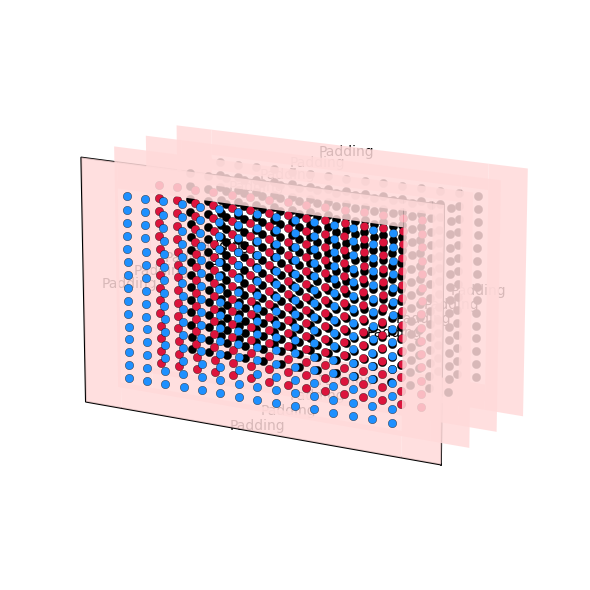

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ── easy-to-tweak knobs ────────────────────────────────────────────────────
n_points_per_side = 15       # inner lattice size (15 × 15)
padding           = 2        # padding cells around the grid
n_layers          = 4        # number of slices
point_spacing     = 0.1      # distance between neighbouring dots
layer_spacing_y   = 2.0      # gap (depth) between successive slices
pad_color         = "#FFDADA"
edge_color        = "#000000"   # outline colour (make it darker to pop)
outline_lift      = 0.01       # extra +y so the outline sits in front
# ───────────────────────────────────────────────────────────────────────────

def colour_for_layer(k):            # per-slice point colour
    return {0: "dodgerblue", 1: "crimson"}.get(k, "black")

# inner scatter coordinates (x, z)
xs_inner, zs_inner = np.meshgrid(
    np.arange(n_points_per_side) * point_spacing,
    np.arange(n_points_per_side) * point_spacing
)
xs_inner, zs_inner = xs_inner.ravel(), zs_inner.ravel()

# derive extents from the knobs ------------------------------------------------
inner_min = 0.0
inner_max = (n_points_per_side - 1) * point_spacing

outer_min = inner_min - (padding + 0.5) * point_spacing
outer_max = inner_max + (padding + 0.5) * point_spacing

left_x1   = inner_min - 0.5 * point_spacing
right_x0  = inner_max + 0.5 * point_spacing
bottom_z1 = inner_min - 0.5 * point_spacing
top_z0    = inner_max + 0.5 * point_spacing

mid_z = 0.5 * (outer_min + outer_max)
mid_x = mid_z                                 # identical formula

fig = plt.figure(figsize=(6.5, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.set_box_aspect([1.6, 0.7, 1])              # [x : y : z]

# ░░░ 1. Draw from BACK to FRONT so the foremost slice is plotted last ░░░
for k in reversed(range(n_layers)):
    y_c = -k * layer_spacing_y                # slices recede along −y

    # ── pink padding strips (four thin quads) ────────────────────────────
    borders = [
        # left
        [(outer_min, y_c, outer_min), (left_x1, y_c, outer_min),
         (left_x1,  y_c, outer_max), (outer_min, y_c, outer_max)],
        # right
        [(right_x0, y_c, outer_min), (outer_max, y_c, outer_min),
         (outer_max, y_c, outer_max), (right_x0, y_c, outer_max)],
        # bottom
        [(left_x1,  y_c, outer_min), (right_x0, y_c, outer_min),
         (right_x0, y_c, bottom_z1), (left_x1,  y_c, bottom_z1)],
        # top
        [(left_x1,  y_c, top_z0),    (right_x0, y_c, top_z0),
         (right_x0, y_c, outer_max), (left_x1,  y_c, outer_max)],
    ]
    ax.add_collection3d(
        Poly3DCollection(borders,
                         facecolors=pad_color,
                         alpha=0.85,
                         linewidths=0)
    )

    # ── inner scatter points (solid colour per slice) ────────────────────
    ax.scatter(xs_inner,
               np.full_like(xs_inner, y_c) + 0.02,
               zs_inner,
               c=colour_for_layer(k),
               s=36, edgecolors="k", linewidths=0.25,
               depthshade=False)

    # ── one centred “Padding” label per strip ────────────────────────────
    ax.text(0.5*(outer_min+left_x1),  y_c, mid_z,
            "Padding", ha="right",  va="center", rotation=90)
    ax.text(0.5*(right_x0+outer_max), y_c, mid_z,
            "Padding", ha="left",   va="center", rotation=270)
    ax.text(mid_x, y_c, 0.5*(outer_min+bottom_z1),
            "Padding", ha="center", va="top")
    ax.text(mid_x, y_c, 0.5*(top_z0+outer_max),
            "Padding", ha="center", va="bottom")

    # save outline vertices for this slice – we’ll draw them **later**
    if k == 0:        # remember the *front-most* slice only
        front_outline = [
            (outer_min, y_c, outer_min),
            (outer_max, y_c, outer_min),
            (outer_max, y_c, outer_max),
            (outer_min, y_c, outer_max),
            (outer_min, y_c, outer_min)
        ]

# ░░░ 2. Redraw the front outline a smidge closer to the camera ░░░
xs, ys, zs = zip(*front_outline)
ys = np.array(ys) + outline_lift               # ∆y > 0 ⇒ nearer camera
ax.plot(xs, ys, zs, color=edge_color, linewidth=1.3)

# ░░░ 3. Camera & cosmetics ░░░
ax.view_init(elev=15, azim=120)                # left-skew, shallow view
ax.set_axis_off()
plt.tight_layout()
plt.show()
